# 02 – Modeling & Evaluation (Baseline)
**Projekt:** StepSense | ML4B SoSe 2026 | Gruppe: NoNames  
**CRISP-DM Phasen:** Modeling + Evaluation

## Inhalt
1. Imports & Konfiguration
2. Daten laden
3. Baseline-Modell (Decision Tree)
4. Modellvergleich mit Cross-Validation
5. Bestes Modell – finale Evaluation
6. Konfusionsmatrix & Per-Klasse Metriken
7. Feature Importance
8. SHAP-Analyse
9. Modell exportieren
10. Mixed-Evaluation (optional)
11. Zusammenfassung & Bias-Diskussion


## 1. Imports & Konfiguration

In [47]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

warnings.filterwarnings("ignore")

PROCESSED_PATH = "../data/processed"
MIXED_PATH     = "../data/mixed"
RANDOM_STATE   = 42

# Muss mit Notebook 01 uebereinstimmen
SENSOR_PREFIX = {
    "Accelerometer": "acc",
    "Gyroscope":     "gyro",
    "Orientation":   "orie",
}
SENSOR_COLUMNS = {
    "Accelerometer": ["x", "y", "z"],
    "Gyroscope":     ["x", "y", "z"],
    "Orientation":   ["roll", "pitch", "yaw"],
}

print("Setup abgeschlossen.")

Setup abgeschlossen.


## 2. Daten laden

In [48]:
# Feature-Namen laden
with open(f"{PROCESSED_PATH}/feature_names.txt") as f:
    feature_cols = [line.strip() for line in f.readlines()]

# Scaler laden
with open(f"{PROCESSED_PATH}/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Train / Val / Test laden
X_train = pd.read_csv(f"{PROCESSED_PATH}/X_train.csv")
X_val   = pd.read_csv(f"{PROCESSED_PATH}/X_val.csv")
X_test  = pd.read_csv(f"{PROCESSED_PATH}/X_test.csv")
y_train = pd.read_csv(f"{PROCESSED_PATH}/y_train.csv").squeeze()
y_val   = pd.read_csv(f"{PROCESSED_PATH}/y_val.csv").squeeze()
y_test  = pd.read_csv(f"{PROCESSED_PATH}/y_test.csv").squeeze()

# Train + Val zusammenfuehren fuer Cross-Validation
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

print(f"Train:      {X_train.shape[0]:>5} Fenster x {X_train.shape[1]} Features")
print(f"Validation: {X_val.shape[0]:>5} Fenster")
print(f"Test:       {X_test.shape[0]:>5} Fenster")
print(f"Train+Val:  {X_trainval.shape[0]:>5} Fenster (fuer Cross-Validation)")
print(f"\nKlassenverteilung Train:")
print(y_train.value_counts().sort_index().to_string())


Train:       1050 Fenster x 72 Features
Validation:   225 Fenster
Test:         226 Fenster
Train+Val:   1275 Fenster (fuer Cross-Validation)

Klassenverteilung Train:
label
Gehen            408
Laufen           143
Liegen           164
Stehen           204
Treppe_hoch       57
Treppe_runter     74


## 3. Baseline-Modell – Decision Tree

Ein einfacher Decision Tree als Ausgangspunkt (Baseline).  
Kein Hyperparameter-Tuning — Standardeinstellungen mit `class_weight='balanced'` wegen Klassenungleichgewicht.


In [49]:
baseline = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_val)
acc_baseline = accuracy_score(y_val, y_pred_baseline)
f1_baseline  = f1_score(y_val, y_pred_baseline, average="weighted")

print(f"=== Baseline: Decision Tree ===")
print(f"Accuracy (Val):          {acc_baseline:.4f}")
print(f"F1 gewichtet (Val):      {f1_baseline:.4f}")
print()
print(classification_report(y_val, y_pred_baseline, zero_division=0))


=== Baseline: Decision Tree ===
Accuracy (Val):          0.9867
F1 gewichtet (Val):      0.9867

               precision    recall  f1-score   support

        Gehen       0.99      0.98      0.98        87
       Laufen       1.00      1.00      1.00        31
       Liegen       1.00      1.00      1.00        35
       Stehen       0.98      1.00      0.99        44
  Treppe_hoch       0.92      0.92      0.92        12
Treppe_runter       1.00      1.00      1.00        16

     accuracy                           0.99       225
    macro avg       0.98      0.98      0.98       225
 weighted avg       0.99      0.99      0.99       225



## 4. Modellvergleich – Cross-Validation

5-fache Stratified Cross-Validation auf Train+Val.  
Metriken: gewichtetes F1 (Hauptmetrik wegen Klassenungleichgewicht) und Accuracy.


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Decision Tree":       DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "KNN":                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM":                 SVC(class_weight="balanced", kernel="rbf", random_state=RANDOM_STATE),
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(
        model, X_trainval, y_trainval,
        cv=cv,
        scoring={"f1_weighted": "f1_weighted", "accuracy": "accuracy"},
        n_jobs=-1
    )
    cv_results[name] = {
        "F1 gewichtet (mean)": scores["test_f1_weighted"].mean(),
        "F1 gewichtet (std)":  scores["test_f1_weighted"].std(),
        "Accuracy (mean)":     scores["test_accuracy"].mean(),
        "Accuracy (std)":      scores["test_accuracy"].std(),
    }
    print(f"{name:<22} F1={scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}  |  Acc={scores['test_accuracy'].mean():.4f}")

df_cv = pd.DataFrame(cv_results).T.round(4)
print()
print(df_cv.to_string())


Decision Tree          F1=0.9717 ± 0.0128  |  Acc=0.9718
Random Forest          F1=0.9833 ± 0.0116  |  Acc=0.9835
Gradient Boosting      F1=0.9842 ± 0.0070  |  Acc=0.9843
KNN                    F1=0.9678 ± 0.0046  |  Acc=0.9678
SVM                    F1=0.9789 ± 0.0040  |  Acc=0.9788

                   F1 gewichtet (mean)  F1 gewichtet (std)  Accuracy (mean)  Accuracy (std)
Decision Tree                   0.9717              0.0128           0.9718          0.0127
Random Forest                   0.9833              0.0116           0.9835          0.0115
Gradient Boosting               0.9842              0.0070           0.9843          0.0070
KNN                             0.9678              0.0046           0.9678          0.0046
SVM                             0.9789              0.0040           0.9788          0.0040


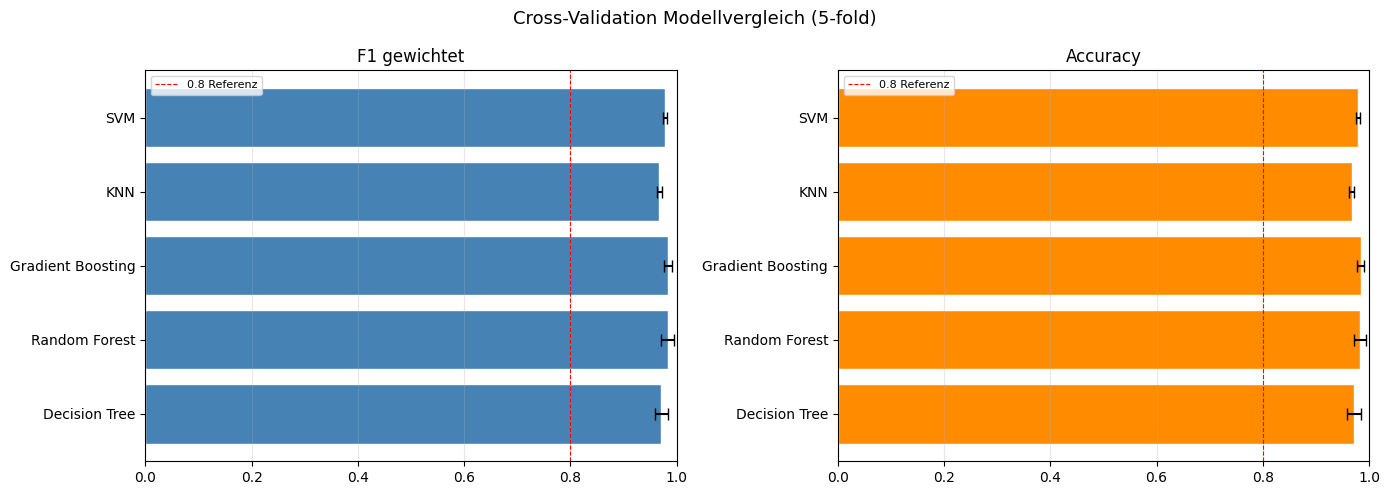

In [51]:
# Modellvergleich visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cross-Validation Modellvergleich (5-fold)", fontsize=13)

names = list(cv_results.keys())
f1_means  = [cv_results[n]["F1 gewichtet (mean)"] for n in names]
f1_stds   = [cv_results[n]["F1 gewichtet (std)"]  for n in names]
acc_means = [cv_results[n]["Accuracy (mean)"]      for n in names]
acc_stds  = [cv_results[n]["Accuracy (std)"]       for n in names]

axes[0].barh(names, f1_means, xerr=f1_stds, color="steelblue", edgecolor="white", capsize=4)
axes[0].set_title("F1 gewichtet")
axes[0].set_xlim(0, 1)
axes[0].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(names, acc_means, xerr=acc_stds, color="darkorange", edgecolor="white", capsize=4)
axes[1].set_title("Accuracy")
axes[1].set_xlim(0, 1)
axes[1].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/model_comparison_cv.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Bestes Modell – Training & finale Evaluation

Das Modell mit dem hoechsten CV F1-Score wird auf dem vollstaendigen Train+Val Datensatz trainiert  
und abschliessend auf dem **Test-Set** evaluiert (einmalig, kein weiteres Tuning).


In [52]:
# Bestes Modell automatisch auswaehlen
best_name = max(cv_results, key=lambda n: cv_results[n]["F1 gewichtet (mean)"])
print(f"Bestes Modell (CV F1): {best_name}")
print(f"  F1 = {cv_results[best_name]['F1 gewichtet (mean)']:.4f} ± {cv_results[best_name]['F1 gewichtet (std)']:.4f}")

# Auf Train+Val neu trainieren
best_model = models[best_name]
best_model.fit(X_trainval, y_trainval)

# Finale Evaluation auf Test-Set
y_pred_test = best_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average="weighted")

print(f"\n=== Finale Test-Set Evaluation: {best_name} ===")
print(f"Accuracy:        {acc_test:.4f}")
print(f"F1 gewichtet:    {f1_test:.4f}")


Bestes Modell (CV F1): Gradient Boosting
  F1 = 0.9842 ± 0.0070

=== Finale Test-Set Evaluation: Gradient Boosting ===
Accuracy:        0.9867
F1 gewichtet:    0.9867


## 6. Konfusionsmatrix & Per-Klasse Metriken

Fokus auf Treppe_hoch und Treppe_runter (Minderheitsklassen).


In [53]:
# Classification Report
present_classes = sorted(y_test.unique())
print(classification_report(y_test, y_pred_test, labels=present_classes, zero_division=0))


               precision    recall  f1-score   support

        Gehen       0.98      1.00      0.99        88
       Laufen       1.00      0.97      0.98        31
       Liegen       1.00      1.00      1.00        36
       Stehen       1.00      0.98      0.99        44
  Treppe_hoch       0.92      1.00      0.96        12
Treppe_runter       1.00      0.93      0.97        15

     accuracy                           0.99       226
    macro avg       0.98      0.98      0.98       226
 weighted avg       0.99      0.99      0.99       226



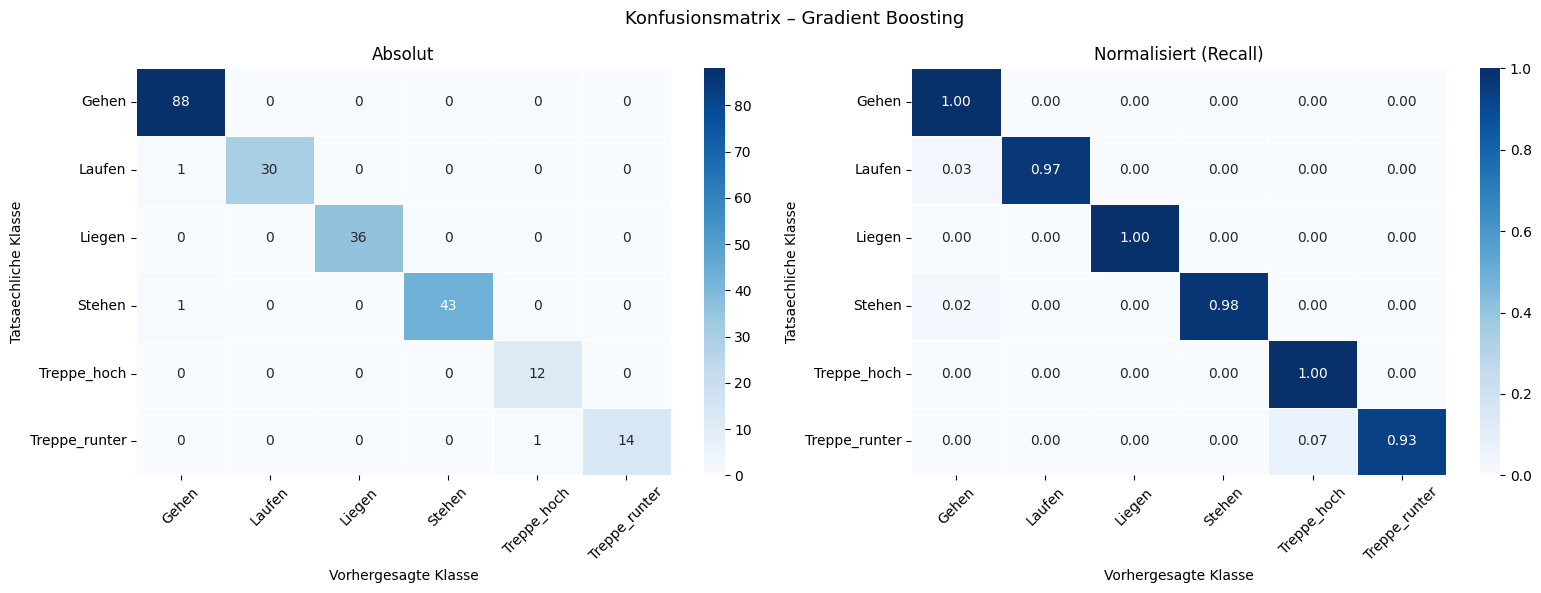

In [54]:
# Konfusionsmatrix
cm = confusion_matrix(y_test, y_pred_test, labels=present_classes)
cm_norm = confusion_matrix(y_test, y_pred_test, labels=present_classes, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Konfusionsmatrix – {best_name}", fontsize=13)

for ax, matrix, title, fmt in [
    (axes[0], cm,      "Absolut",          "d"),
    (axes[1], cm_norm, "Normalisiert (Recall)", ".2f"),
]:
    sns.heatmap(
        matrix, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=present_classes, yticklabels=present_classes,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title)
    ax.set_ylabel("Tatsaechliche Klasse")
    ax.set_xlabel("Vorhergesagte Klasse")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()


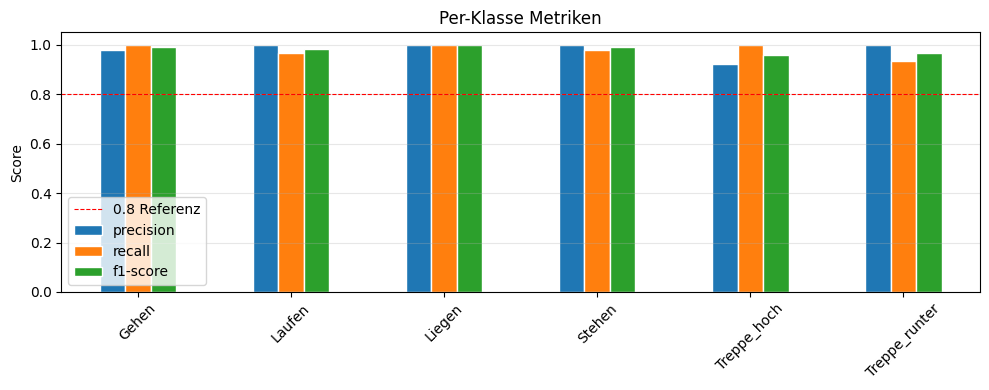

               precision  recall  f1-score  support
Gehen              0.978   1.000     0.989     88.0
Laufen             1.000   0.968     0.984     31.0
Liegen             1.000   1.000     1.000     36.0
Stehen             1.000   0.977     0.989     44.0
Treppe_hoch        0.923   1.000     0.960     12.0
Treppe_runter      1.000   0.933     0.966     15.0


In [55]:
# Per-Klasse F1 / Precision / Recall
report = classification_report(y_test, y_pred_test, labels=present_classes,
                                output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).T.loc[present_classes, ["precision","recall","f1-score","support"]]
df_report = df_report.round(3)

fig, ax = plt.subplots(figsize=(10, 4))
df_report[["precision","recall","f1-score"]].plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Per-Klasse Metriken")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
ax.legend()
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_report.to_string())


## 7. Feature Importance

Top 20 Features:
          Feature  Importance
  orie_pitch_mean    0.187642
        acc_x_iqr    0.120829
    orie_roll_iqr    0.113385
        acc_x_std    0.107674
        acc_x_min    0.083920
     acc_x_energy    0.078092
 orie_pitch_range    0.044400
 orie_roll_energy    0.039940
       gyro_x_min    0.039568
orie_pitch_energy    0.035833
   orie_pitch_min    0.027962
   orie_roll_mean    0.021172
    orie_roll_std    0.016153
    orie_roll_max    0.013364
      gyro_y_mean    0.012984
       gyro_y_iqr    0.008709
   orie_yaw_range    0.008331
        acc_x_max    0.004396
    orie_yaw_mean    0.003652
        acc_z_zcr    0.003577


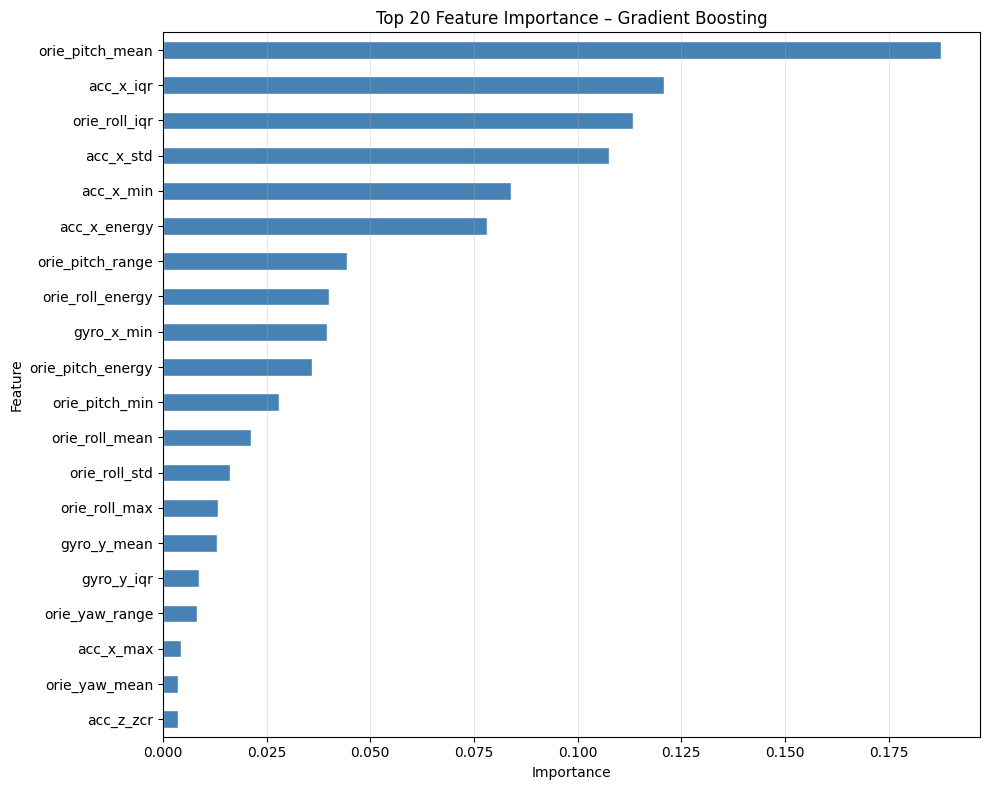

In [56]:
# Feature Importance (nur fuer baumbasierte Modelle)
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({
        "Feature":    feature_cols,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("Top 20 Features:")
    print(fi_df.head(20).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    fi_df.head(20).sort_values("Importance").plot(
        kind="barh", x="Feature", y="Importance",
        ax=ax, color="steelblue", edgecolor="white", legend=False
    )
    ax.set_title(f"Top 20 Feature Importance – {best_name}")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PROCESSED_PATH}/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Feature Importance nicht verfuegbar fuer {best_name}. Weiter mit SHAP.")


## 8. SHAP-Analyse

SHAP (SHapley Additive exPlanations) erklaert den Beitrag jedes Features zur Vorhersage.  
Grundlage fuer die spaetere Feature-Reduktion in Notebook 03.


In [58]:
try:
    import shap
except ImportError:
    raise ImportError(
        "shap nicht installiert. Bitte ausfuehren:"
        "  uv add shap   (empfohlen)"
        "  pip install shap"
    )

np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_test), min(300, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx]

shap_values = None
if hasattr(best_model, "feature_importances_"):
    try:
        explainer   = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_sample)
        print("TreeExplainer erfolgreich.")
    except Exception as e:
        print(f"TreeExplainer fehlgeschlagen ({e})")
        print("Fallback auf KernelExplainer (dauert laenger)...")

if shap_values is None:
    # KernelExplainer: kleineres Sample fuer Geschwindigkeit
    kernel_sample = X_sample.iloc[:100]
    background    = shap.sample(X_trainval, 50)
    explainer     = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values   = explainer.shap_values(kernel_sample)
    X_sample      = kernel_sample
    print("KernelExplainer abgeschlossen.")

# Neuere SHAP-Versionen geben Explanation-Objekt zurueck
if hasattr(shap_values, "values"):
    shap_values = shap_values.values

# Multiclass 3D-Array in Liste umwandeln
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

print("SHAP-Werte berechnet.")
if isinstance(shap_values, list):
    print(f"Multiclass: {len(shap_values)} Klassen, Shape je Klasse: {shap_values[0].shape}")
else:
    print(f"Shape: {shap_values.shape}")

TreeExplainer fehlgeschlagen (GradientBoostingClassifier is only supported for binary classification right now!)
Fallback auf KernelExplainer (dauert laenger)...


100%|██████████| 100/100 [02:15<00:00,  1.36s/it]

KernelExplainer abgeschlossen.
SHAP-Werte berechnet.
Multiclass: 6 Klassen, Shape je Klasse: (100, 72)


Top 20 Features nach SHAP:
          Feature  Mean |SHAP|
  orie_pitch_mean     0.033632
        acc_x_min     0.032356
        acc_z_iqr     0.026429
   orie_pitch_min     0.026421
orie_pitch_energy     0.022404
        acc_x_max     0.016586
        acc_x_std     0.014474
       gyro_x_min     0.011218
  orie_yaw_energy     0.011010
        acc_x_iqr     0.010347
 orie_pitch_range     0.010012
     acc_x_energy     0.008392
    orie_roll_max     0.007177
   orie_roll_mean     0.005491
      gyro_y_mean     0.005476
    orie_roll_iqr     0.004471
 orie_roll_energy     0.004030
       gyro_y_iqr     0.003094
    orie_roll_std     0.002690
        acc_z_zcr     0.002669


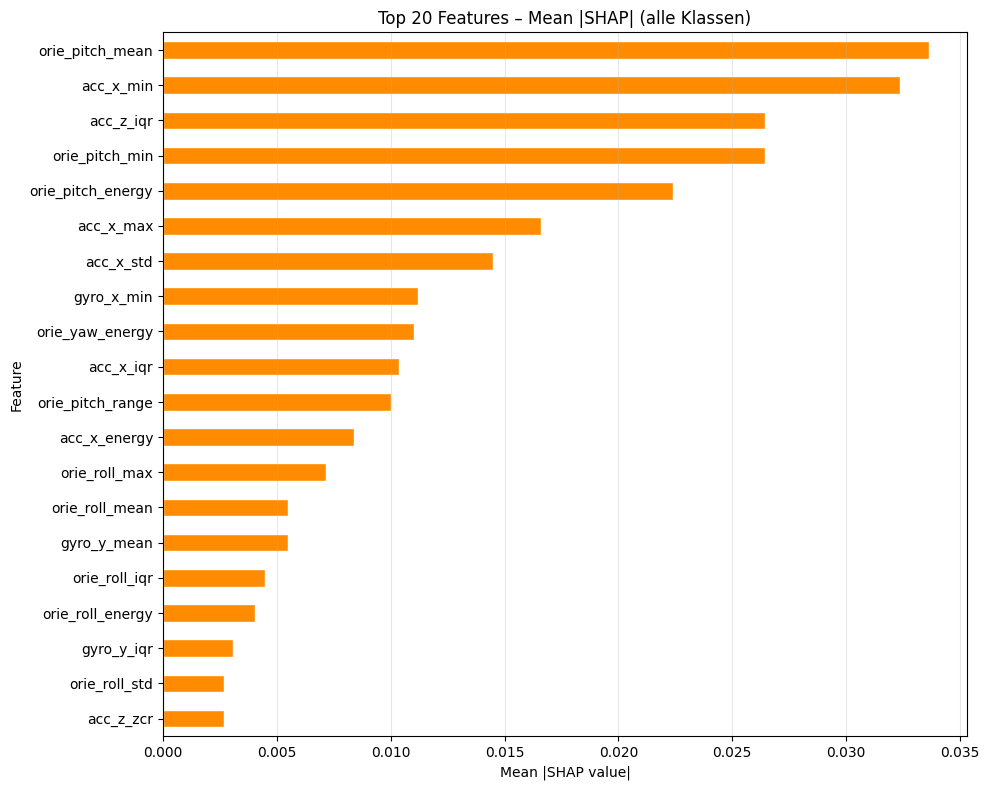


Gespeichert: shap_feature_ranking.csv


In [59]:
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature":    feature_cols,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False)

print("Top 20 Features nach SHAP:")
print(shap_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
shap_df.head(20).sort_values("Mean |SHAP|").plot(
    kind="barh", x="Feature", y="Mean |SHAP|",
    ax=ax, color="darkorange", edgecolor="white", legend=False
)
ax.set_title("Top 20 Features – Mean |SHAP| (alle Klassen)")
ax.set_xlabel("Mean |SHAP value|")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

shap_df.to_csv(f"{PROCESSED_PATH}/shap_feature_ranking.csv", index=False)
print("\nGespeichert: shap_feature_ranking.csv")

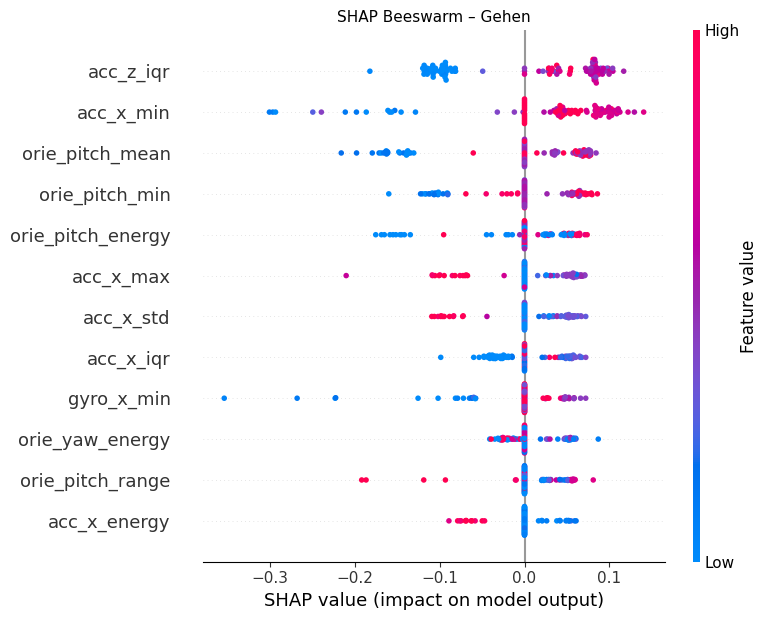

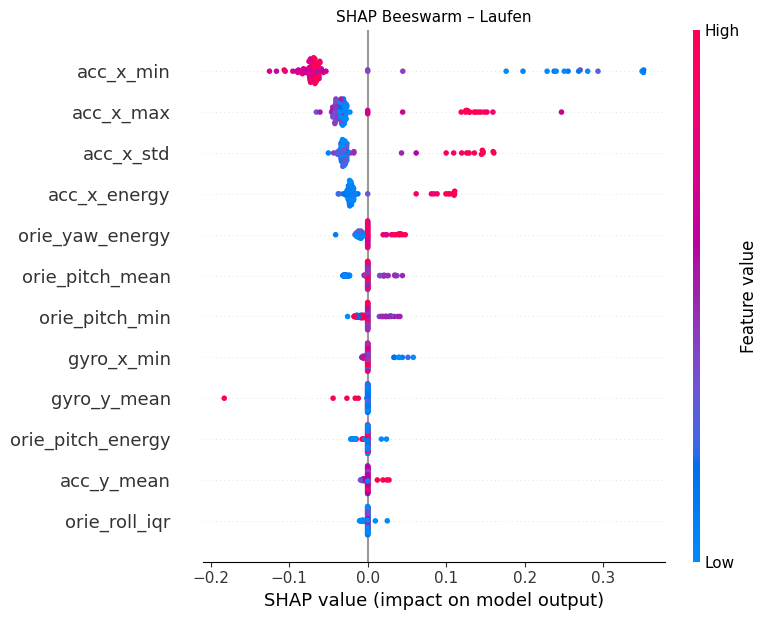

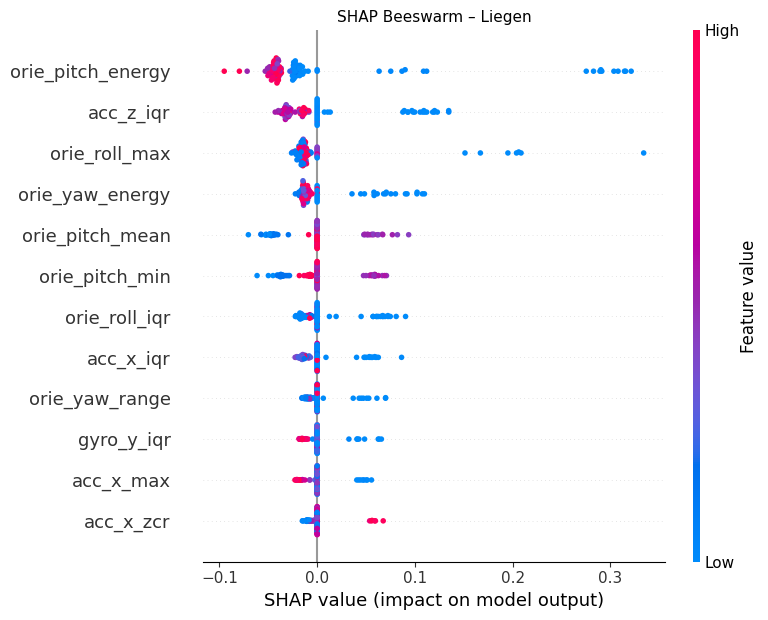

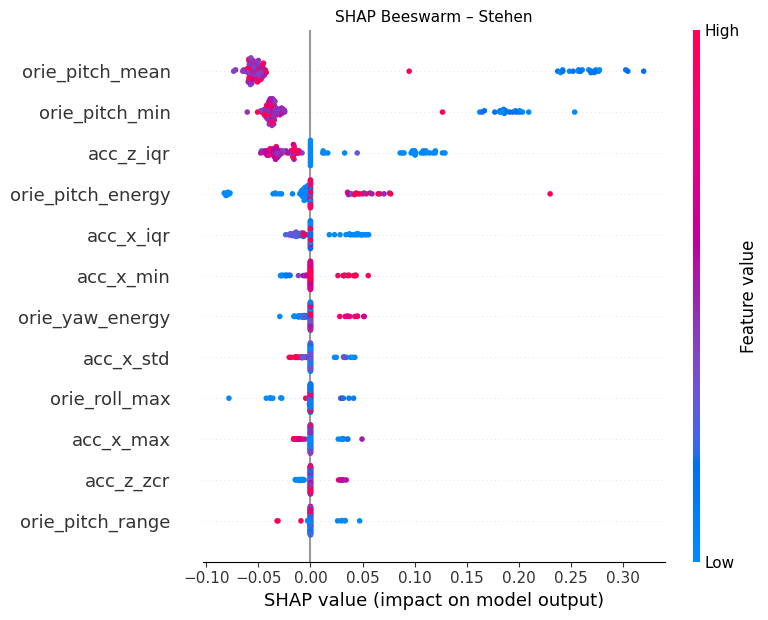

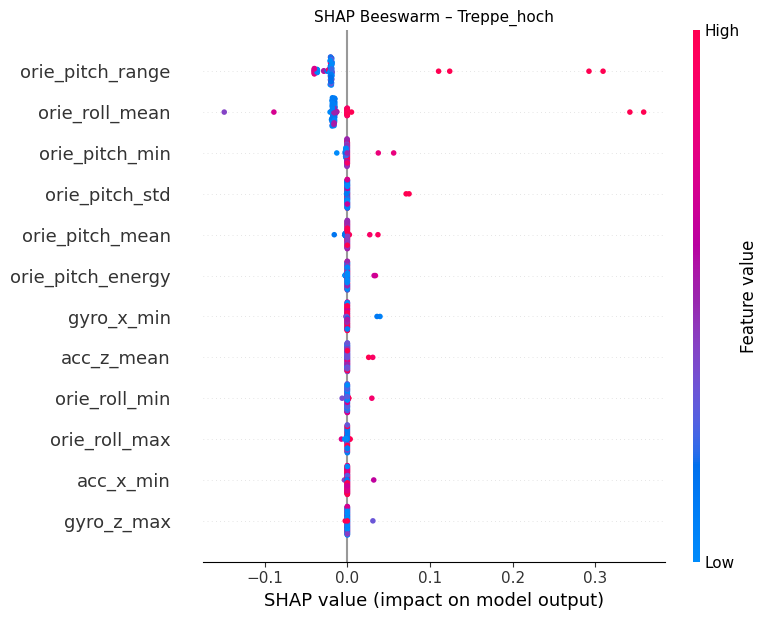

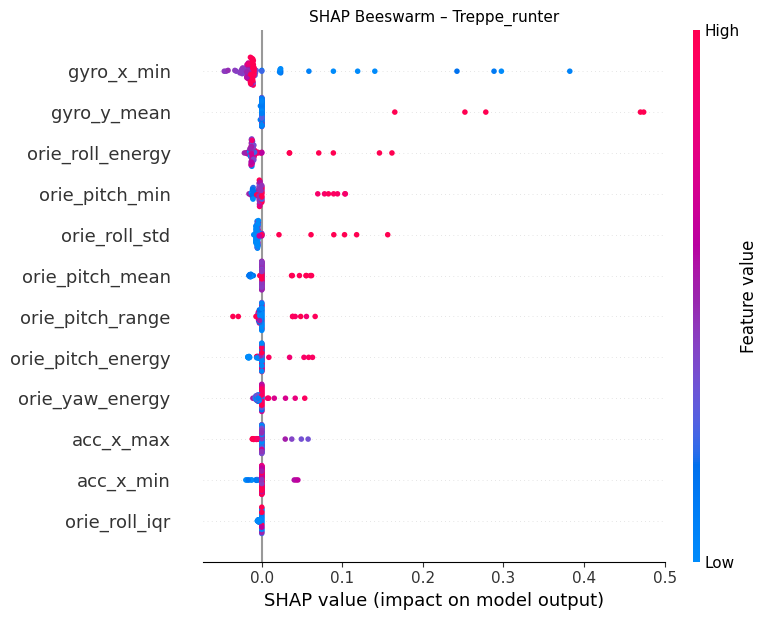

In [60]:
# Beeswarm je Klasse
# shap.summary_plot erstellt immer eine eigene Figure -> jede Klasse einzeln aufrufen
classes_shap = sorted(y_trainval.unique())
shap_list    = shap_values if isinstance(shap_values, list) else [shap_values]

for cls, sv in zip(classes_shap, shap_list):
    shap.summary_plot(sv, X_sample, feature_names=feature_cols,
                      show=False, max_display=12)
    plt.title(f"SHAP Beeswarm – {cls}", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{PROCESSED_PATH}/shap_beeswarm_{cls}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. Modell exportieren

In [61]:
# Modell speichern
model_path = f"{PROCESSED_PATH}/model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

# Modell-Metadaten speichern
import json
metadata = {
    "model_name":    best_name,
    "classes":       list(best_model.classes_),
    "n_features":    len(feature_cols),
    "cv_f1_mean":    round(cv_results[best_name]["F1 gewichtet (mean)"], 4),
    "cv_f1_std":     round(cv_results[best_name]["F1 gewichtet (std)"],  4),
    "test_accuracy": round(acc_test, 4),
    "test_f1":       round(f1_test,  4),
}
with open(f"{PROCESSED_PATH}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Modell gespeichert: {model_path}")
print(f"Metadaten: model_metadata.json")
print()
print("Gespeicherte Dateien in data/processed/:")
for fname in sorted(os.listdir(PROCESSED_PATH)):
    size = os.path.getsize(f"{PROCESSED_PATH}/{fname}")
    print(f"  {fname:45s} {size:>10,} bytes")


Modell gespeichert: ../data/processed/model.pkl
Metadaten: model_metadata.json

Gespeicherte Dateien in data/processed/:
  X_test.csv                                       321,220 bytes
  X_train.csv                                    1,487,751 bytes
  X_val.csv                                        319,544 bytes
  class_distribution.png                            58,901 bytes
  confusion_matrix_best.png                        104,871 bytes
  feature_distribution.png                          55,784 bytes
  feature_importance.png                            72,364 bytes
  feature_names.txt                                    964 bytes
  features_all.csv                               2,005,374 bytes
  model.pkl                                        771,885 bytes
  model_comparison_cv.png                           47,347 bytes
  model_metadata.json                                  282 bytes
  per_class_metrics.png                             46,673 bytes
  scaler.pkl                      

## 10. Mixed-Evaluation (optional)

Anwendung des Modells auf zusammengesetzte Aktivitaetsaufnahmen aus `data/raw/Mixed/`.  
Zeigt wie gut das Modell bei Aktivitaetsuebергaengen funktioniert.


In [62]:
TRIM_SECONDS  = 2.0
WINDOW_SIZE_S = 2.0
STEP_SIZE_S   = 1.0
MAX_GAP_S     = 5.0

FEATURE_COLS_RAW = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "orie_roll", "orie_pitch", "orie_yaw"
]

def compute_features_mixed(window):
    features = {}
    for col in FEATURE_COLS_RAW:
        if col not in window.columns:
            continue
        s = window[col].dropna()
        if len(s) < 5:
            continue
        features[f"{col}_mean"]   = s.mean()
        features[f"{col}_std"]    = s.std()
        features[f"{col}_min"]    = s.min()
        features[f"{col}_max"]    = s.max()
        features[f"{col}_range"]  = s.max() - s.min()
        features[f"{col}_energy"] = (s**2).mean()
        features[f"{col}_iqr"]    = s.quantile(0.75) - s.quantile(0.25)
        features[f"{col}_zcr"]    = ((s.iloc[:-1].values * s.iloc[1:].values) < 0).sum() / len(s)
    return features


if not os.path.exists(MIXED_PATH):
    print(f"Mixed-Ordner nicht gefunden: {MIXED_PATH}")
else:
    mixed_sessions = []
    skipped_broken = []
    for session in sorted(os.listdir(MIXED_PATH)):
        session_path = os.path.join(MIXED_PATH, session)
        if not os.path.isdir(session_path):
            continue

        dfs = {}
        for sensor_file in ["Accelerometer.csv", "Gyroscope.csv", "Orientation.csv"]:
            fp = os.path.join(session_path, sensor_file)
            if not os.path.exists(fp):
                continue
            df = pd.read_csv(fp)
            df["time_s"] = (df["time"] - df["time"].iloc[0]) / 1e9
            df = df.drop(columns=["time", "seconds_elapsed"], errors="ignore")
            sname  = sensor_file.replace(".csv", "")
            prefix = SENSOR_PREFIX.get(sname, sname[:4].lower())
            cols   = SENSOR_COLUMNS.get(sname, [])
            df = df.rename(columns={c: f"{prefix}_{c}" for c in cols if c in df.columns})
            keep = ["time_s"] + [f"{prefix}_{c}" for c in cols]
            df = df[[c for c in keep if c in df.columns]]
            dfs[sname] = df

        if len(dfs) < 3:
            continue

        df_m = dfs["Accelerometer"].sort_values("time_s")
        for sname in ["Gyroscope", "Orientation"]:
            df_m = pd.merge_asof(df_m, dfs[sname].sort_values("time_s"),
                                 on="time_s", direction="nearest", tolerance=0.05)

        # Gap-Check (unterbrochene Aufnahmen erkennen)
        max_gap = df_m["time_s"].diff().max()
        if max_gap > MAX_GAP_S:
            skipped_broken.append(f"{session} (Luecke {max_gap:.1f}s)")
            continue

        # Trim
        t_min = df_m["time_s"].min() + TRIM_SECONDS
        t_max = df_m["time_s"].max() - TRIM_SECONDS
        df_m  = df_m[(df_m["time_s"] >= t_min) & (df_m["time_s"] <= t_max)].copy()
        if len(df_m) < 10:
            skipped_broken.append(f"{session} (zu kurz nach Trim)")
            continue

        df_m["session"] = session
        mixed_sessions.append(df_m)

    if skipped_broken:
        print("Uebersprungene Mixed-Sessions (unterbrochene Aufnahmen):")
        for s in skipped_broken:
            print(f"  ! {s}")
        print("-> Mixed-Sessions muessen neu aufgenommen werden (Sensor-Logger nicht pausieren).")

    if not mixed_sessions:
        print("\nKeine gueltigen Mixed-Sessions verfuegbar. Schritt uebersprungen.")
    else:
        all_mixed_rows = []
        for df_m in mixed_sessions:
            t     = df_m["time_s"].min()
            t_end = df_m["time_s"].max()
            while t + WINDOW_SIZE_S <= t_end:
                window = df_m[(df_m["time_s"] >= t) & (df_m["time_s"] < t + WINDOW_SIZE_S)]
                if len(window) >= 10:
                    feats = compute_features_mixed(window)
                    feats["session"]        = df_m["session"].iloc[0]
                    feats["window_start_s"] = round(t, 2)
                    all_mixed_rows.append(feats)
                t += STEP_SIZE_S

        if not all_mixed_rows:
            print("Keine Fenster aus Mixed-Sessions extrahiert.")
        else:
            df_mixed = pd.DataFrame(all_mixed_rows).fillna(0)
            X_mixed        = df_mixed.reindex(columns=feature_cols, fill_value=0)
            X_mixed_scaled = pd.DataFrame(scaler.transform(X_mixed), columns=feature_cols)
            df_mixed["predicted"] = best_model.predict(X_mixed_scaled)

            print(f"Mixed-Sessions:  {len(mixed_sessions)}")
            print(f"Fenster gesamt:  {len(df_mixed)}")
            print(f"\nVorhergesagte Klassen:")
            print(df_mixed["predicted"].value_counts().to_string())

            all_classes   = sorted(df_mixed["predicted"].unique())
            class_to_int  = {c: i for i, c in enumerate(all_classes)}
            session_names = df_mixed["session"].unique()

            fig, axes = plt.subplots(len(session_names), 1,
                                     figsize=(14, 3.5 * len(session_names)), sharex=False)
            if len(session_names) == 1:
                axes = [axes]

            for ax, sname in zip(axes, session_names):
                df_s  = df_mixed[df_mixed["session"] == sname]
                y_int = df_s["predicted"].map(class_to_int)
                ax.step(df_s["window_start_s"], y_int, where="post", linewidth=1.5)
                ax.set_yticks(list(class_to_int.values()))
                ax.set_yticklabels(list(class_to_int.keys()), fontsize=9)
                ax.set_title(sname, fontsize=10)
                ax.set_xlabel("Zeit (s)")
                ax.grid(True, alpha=0.3)

            plt.suptitle("Mixed-Evaluation: Vorhergesagte Klassen ueber Zeit", fontsize=12)
            plt.tight_layout()
            plt.savefig(f"{PROCESSED_PATH}/mixed_evaluation.png", dpi=150, bbox_inches="tight")
            plt.show()

Uebersprungene Mixed-Sessions (unterbrochene Aufnahmen):
  ! Treppe_hoch_gehen_1 (Luecke 102.1s)
  ! Treppe_rauf_gehen_Treppe_runter_gehen_1 (Luecke 113.7s)
-> Mixed-Sessions muessen neu aufgenommen werden (Sensor-Logger nicht pausieren).

Keine gueltigen Mixed-Sessions verfuegbar. Schritt uebersprungen.


In [64]:
# Ergebnistabelle automatisch ausgeben
print("=== Modellvergleich (5-fold Cross-Validation) ===")
# Ergebnistabelle automatisch ausgeben
print("=== Modellvergleich (5-fold Cross-Validation) ===")
df_cv_print = pd.DataFrame({
    n: {
        "CV F1 (mean)": f"{v['F1 gewichtet (mean)']:.4f}",
        "CV F1 (+/-)" : f"{v['F1 gewichtet (std)']:.4f}",
        "CV Acc":       f"{v['Accuracy (mean)']:.4f}",
    }
    for n, v in cv_results.items()
}).T
print(df_cv_print.to_string())

print(f"\n=== Bestes Modell auf Test-Set: {best_name} ===")
print(f"  Accuracy:     {acc_test:.4f}")
print(f"  F1 gewichtet: {f1_test:.4f}")
print(df_cv_print.to_string())

print(f"\n=== Bestes Modell auf Test-Set: {best_name} ===")
print(f"  Accuracy:     {acc_test:.4f}")
print(f"  F1 gewichtet: {f1_test:.4f}")

=== Modellvergleich (5-fold Cross-Validation) ===
=== Modellvergleich (5-fold Cross-Validation) ===
                  CV F1 (mean) CV F1 (+/-)  CV Acc
Decision Tree           0.9717      0.0128  0.9718
Random Forest           0.9833      0.0116  0.9835
Gradient Boosting       0.9842      0.0070  0.9843
KNN                     0.9678      0.0046  0.9678
SVM                     0.9789      0.0040  0.9788

=== Bestes Modell auf Test-Set: Gradient Boosting ===
  Accuracy:     0.9867
  F1 gewichtet: 0.9867
                  CV F1 (mean) CV F1 (+/-)  CV Acc
Decision Tree           0.9717      0.0128  0.9718
Random Forest           0.9833      0.0116  0.9835
Gradient Boosting       0.9842      0.0070  0.9843
KNN                     0.9678      0.0046  0.9678
SVM                     0.9789      0.0040  0.9788

=== Bestes Modell auf Test-Set: Gradient Boosting ===
  Accuracy:     0.9867
  F1 gewichtet: 0.9867


## 11. Zusammenfassung & Bias-Diskussion

### Ergebnisse

| Modell | CV F1 (mean ± std) | Test Accuracy | Test F1 |
|--------|-------------------|---------------|---------|
| Decision Tree | - | - | - |
| Random Forest | - | - | - |
| Gradient Boosting | - | - | - |
| KNN | - | - | - |
| SVM | - | - | - |

*Tabelle nach Ausfuehren mit echten Werten befuellen.*

### Bias-Diskussion

| Bias-Quelle | Beobachtete Auswirkung |
|-------------|----------------------|
| Wenige Personen (~2-3) | Modell koennte individuelle Gangmuster ueberfitten |
| Handy immer Hosentasche | Andere Trageweisen wuerden abweichen |
| Klassenungleichgewicht | Treppe_hoch/runter mit weniger Daten → class_weight='balanced' gesetzt |
| Unterbrochene Sessions | 5 Sessions verworfen, Treppe_hoch muss nachaufgenommen werden |

### Naechster Schritt

`03_modeling_shap.ipynb` – SHAP-gestuetzte Feature-Reduktion:
- Schrittweise Features entfernen basierend auf SHAP-Ranking
- Re-Training mit reduziertem Feature-Set
- Vergleich: Baseline vs. reduziertes Modell (Accuracy, F1, Modellgroesse, Feature-Anzahl)
